# 2.4 Exploration et nettoyage d'un DataFrame

Avant toute modélisation, il faut savoir ce que contient votre table. Cette leçon déroule une chaîne de préparation standard sur un DataFrame pandas : lire les données, inspecter les types et les statistiques descriptives, traiter les valeurs manquantes, décider quoi faire des zéros, et explorer les corrélations et les distributions par classe.

Le jeu de données est un levé synthétique de géochimie sur roche totale, généré par le paquet du cours `mlgeo_synth`. Chaque ligne est un échantillon de roche avec :

* **les oxydes d'éléments majeurs** (SIO2, AL2O3, FEO, MGO, CAO, NA2O, K2O) en pourcentage massique (wt%),
* **density_g_cm3** : la masse volumique apparente en g/cm3,
* **mag_susc_si** : la susceptibilité magnétique (unités SI),
* **label** : la lithologie (`granite`, `basalt`, `andesite`), qu'un classifieur essaierait plus tard de prédire.

Le générateur implante des corrélations réalistes : un indice latent de différenciation pilote les oxydes, si bien que SiO2 s'anticorrèle avec FeO, MgO et CaO, et que la masse volumique suit les oxydes mafiques. Votre travail dans cette leçon est de retrouver ces relations à partir de la table.

🖥️ [**Diapositives du cours — Séance 05 (ven. 9 oct.)**](https://geo-smart.github.io/mlgeo-book/slides/2026/lec05_tables_that_tell_the_truth.html)

## 1. Lire et explorer les données

In [1]:
import pandas as pd
import numpy as np
import mlgeo_synth

df = mlgeo_synth.geochem_table(n=10000, seed=42)
df.head()

,SIO2,AL2O3,FEO,MGO,CAO,NA2O,K2O,density_g_cm3,mag_susc_si,label
0,45.911630,16.274633,11.975374,9.696094,12.753069,2.080147,0.000000,3.006341,0.000440,basalt
1,68.266983,14.422233,4.859297,2.240226,4.761345,3.047384,3.424764,2.692516,0.000165,granite
2,50.417246,15.268785,8.214010,5.851874,10.378347,2.554201,1.235895,2.939080,0.001338,basalt
3,46.502363,14.569045,11.726829,7.618624,12.454581,1.244922,0.000000,3.001760,0.001120,basalt
4,68.305243,13.592871,3.457937,2.516258,3.781839,3.270665,3.738746,2.682556,0.000087,granite


In [2]:
# what datatypes are in the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SIO2           10000 non-null  float64
 1   AL2O3          10000 non-null  float64
 2   FEO            10000 non-null  float64
 3   MGO            10000 non-null  float64
 4   CAO            10000 non-null  float64
 5   NA2O           10000 non-null  float64
 6   K2O            10000 non-null  float64
 7   density_g_cm3  10000 non-null  float64
 8   mag_susc_si    10000 non-null  float64
 9   label          10000 non-null  str    
dtypes: float64(9), str(1)
memory usage: 847.3 KB


La colonne ``label`` contient des chaînes de caractères, tout le reste est numérique. Vérifiez ensuite les statistiques descriptives. Lisez les lignes min et max à l'aune des attentes physiques : les oxydes doivent se situer entre 0 et 100 wt%, et les masses volumiques des roches crustales entre environ 2,5 et 3,3 g/cm3.

In [3]:
# Summary statistics
df.describe()

,SIO2,AL2O3,FEO,MGO,CAO,NA2O,K2O,density_g_cm3,mag_susc_si
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,62.683048,14.642958,5.518821,3.507023,5.489981,3.176207,2.739503,2.769337,0.000520
std,10.968124,1.148082,3.759978,3.227643,4.436243,0.850818,1.823283,0.144232,0.000606
min,41.686955,11.262724,0.000000,0.000000,0.000000,0.092059,0.000000,2.503250,0.000018
25%,50.103553,13.850434,2.305713,0.613202,1.604526,2.586516,0.926125,2.645018,0.000093
50%,69.214045,14.475739,4.191070,2.201551,3.358273,3.213133,3.210102,2.698103,0.000191
75%,72.294157,15.227731,9.296822,6.856880,10.376314,3.770548,4.309348,2.930363,0.000819
max,81.019298,19.072472,15.184024,11.303776,14.695311,6.731240,7.037632,3.086072,0.006552


In [4]:
# How many samples per lithology?
df['label'].value_counts()

label
granite     5525
basalt      3490
andesite     985
Name: count, dtype: int64

Les classes sont déséquilibrées : les granites sont plus de cinq fois plus nombreux que les andésites. Gardez ce nombre en tête ; il revient dans l'exercice.

## 2. Traiter les valeurs manquantes (NaN)

Les jeux de données de terrain et de laboratoire ont des lacunes : un capteur tombe en panne, un laboratoire saute une analyse, une valeur se perd à la transcription. Dans pandas, les valeurs manquantes apparaissent comme ``NaN`` ou, plus récemment, ``pd.NA``. Stratégies courantes :

* **Supprimer les lignes/colonnes à valeurs manquantes** : acceptable quand la fraction manquante est faible et que l'absence est sans rapport avec la valeur elle-même.
* **Imputer** : combler les lacunes par une moyenne, une médiane, une interpolation ou une estimation par modèle. L'imputation préserve la taille de l'échantillon mais injecte des hypothèses.

Cette table synthétique sort complète du générateur, ce que des données réelles ne sont jamais. Pour donner à la leçon quelque chose à nettoyer, nous supprimons délibérément une petite fraction aléatoire des mesures de masse volumique et de susceptibilité magnétique, et nous mettons quelques valeurs de masse volumique à 0 pour imiter un instrument qui écrit 0 quand une mesure échoue. Ce genre de zéro « sentinelle » est courant dans les archives réelles.

In [5]:
# Deliberately introduce missing data (this is the simulation of a messy archive)
rng = np.random.default_rng(42)

# 2% of density and 3% of susceptibility go missing
mask_density = rng.random(len(df)) < 0.02
mask_susc = rng.random(len(df)) < 0.03
df.loc[mask_density, 'density_g_cm3'] = pd.NA
df.loc[mask_susc, 'mag_susc_si'] = pd.NA

# 15 sentinel zeros in density: the "instrument failure" code
sentinel_rows = rng.choice(len(df), size=15, replace=False)
df.loc[df.index[sentinel_rows], 'density_g_cm3'] = 0.0

In [6]:
# Check for missing values
print(df.isna().sum())

SIO2               0
AL2O3              0
FEO                0
MGO                0
CAO                0
NA2O               0
K2O                0
density_g_cm3    187
mag_susc_si      302
label              0
dtype: int64


Notez le style pandas moderne employé ci-dessus : nous assignons avec ``df.loc[mask, col] = value`` et nous réassignons les résultats (``df = df.something()``) au lieu d'utiliser ``inplace=True`` sur des vues ou des tranches. Les opérations *inplace* chaînées sur une tranche de DataFrame lèvent des erreurs dans pandas 3.

## 3. Les zéros : valeur physique ou code de donnée manquante ?

Un raccourci tentant : « remplacer tous les zéros par NA ». Ne le faites pas. Qu'un zéro soit réel dépend de la physique de la variable :

* **Un MgO proche de 0 wt% est réel.** Les granites très évolués peuvent n'avoir pratiquement plus de magnésium ; le liquide magmatique l'a fractionné. Il en va de même pour FeO, CaO et K2O dans les bons types de roches. Supprimer ces zéros supprimerait préférentiellement les granites évolués et biaiserait le jeu de données.
* **Une masse volumique de 0 g/cm3 est impossible.** Aucune roche n'a une masse volumique nulle. Un zéro, là, est une sentinelle : un code qu'un instrument ou une base de données a utilisé pour dire « pas de mesure ».

La vérification est simple : comptez les zéros par colonne et demandez-vous, pour chaque colonne, si zéro est dans la plage physiquement possible.

In [7]:
# Count zeros per numeric column
numeric_cols = df.select_dtypes(include='number').columns
print((df[numeric_cols] == 0).sum())

SIO2                0
AL2O3               0
FEO               184
MGO              1434
CAO               367
NA2O                0
K2O               824
density_g_cm3      15
mag_susc_si         0
dtype: int64


Des milliers de zéros d'oxydes, et exactement les 15 zéros de masse volumique que nous avions plantés. Regardez maintenant quelles roches portent les zéros de MgO.

In [8]:
# Which lithologies have MgO exactly at 0?
print(df.loc[df['MGO'] == 0, 'label'].value_counts())
print("\nMedian SiO2 of MgO=0 samples:", round(df.loc[df['MGO'] == 0, 'SIO2'].median(), 1), "wt%")
print("Median SiO2 of the full table:", round(df['SIO2'].median(), 1), "wt%")

label
granite     1432
andesite       2
Name: count, dtype: int64

Median SiO2 of MgO=0 samples: 74.2 wt%
Median SiO2 of the full table: 69.2 wt%


Les zéros de MgO sont presque tous des granites, et des granites riches en silice. C'est exactement l'attente géochimique pour des liquides évolués : ces zéros portent de l'information. Nous les gardons.

Les zéros de masse volumique sont une autre histoire. Remplacez seulement ceux-là par ``pd.NA``, par assignation, pas en place (*inplace*).

In [9]:
# Convert only the impossible zeros (density) to missing values
df = df.replace({'density_g_cm3': {0.0: pd.NA}})
print(df.isna().sum())
print("\ndensity dtype after replace:", df['density_g_cm3'].dtype)

SIO2               0
AL2O3              0
FEO                0
MGO                0
CAO                0
NA2O               0
K2O                0
density_g_cm3    202
mag_susc_si      302
label              0
dtype: int64

density dtype after replace: object


Regardez le dtype : `replace` avec ``pd.NA`` a silencieusement converti la colonne de ``float64`` en ``object``. C'est important, car tout appel ``select_dtypes(include='number')`` en aval — les matrices de corrélation, ``describe()`` — écarterait silencieusement la masse volumique, la colonne même que ce nettoyage protégeait. Une colonne peut être numérique par son contenu et non numérique par son dtype, et pandas ne vous préviendra pas. Reconvertissez-la avant de poursuivre, et faites de la vérification des dtypes une partie de chaque étape de nettoyage, pas seulement de la première.

In [10]:
# Cast back to float so density stays numeric downstream
df['density_g_cm3'] = pd.to_numeric(df['density_g_cm3'])
print("density dtype after cast:", df['density_g_cm3'].dtype)

density dtype after cast: float64


## 4. Écarter les lignes incomplètes

La fraction manquante est faible (environ 5 % des lignes ont au moins une lacune) et, par construction ici, sans rapport avec les valeurs elles-mêmes : la suppression est donc défendable. Avec des données réelles, vous vous demanderiez d'abord *pourquoi* des valeurs manquent avant de supprimer quoi que ce soit.

In [11]:
df_cleaned = df.dropna()
print(f"Rows before: {len(df)}, after dropping incomplete rows: {len(df_cleaned)}")
df_cleaned.info()

Rows before: 10000, after dropping incomplete rows: 9499
<class 'pandas.DataFrame'>
Index: 9499 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SIO2           9499 non-null   float64
 1   AL2O3          9499 non-null   float64
 2   FEO            9499 non-null   float64
 3   MGO            9499 non-null   float64
 4   CAO            9499 non-null   float64
 5   NA2O           9499 non-null   float64
 6   K2O            9499 non-null   float64
 7   density_g_cm3  9499 non-null   float64
 8   mag_susc_si    9499 non-null   float64
 9   label          9499 non-null   str    
dtypes: float64(9), str(1)
memory usage: 880.1 KB


In [12]:
# Final check: no missing values, class counts still imbalanced but intact
print(df_cleaned.isna().sum())
print()
print(df_cleaned['label'].value_counts())

SIO2             0
AL2O3            0
FEO              0
MGO              0
CAO              0
NA2O             0
K2O              0
density_g_cm3    0
mag_susc_si      0
label            0
dtype: int64

label
granite     5182
basalt      3357
andesite     960
Name: count, dtype: int64


## 5. Valeurs censurées : présentes mais fausses

Les valeurs manquantes s'annoncent d'elles-mêmes — `isna()` les trouve. Une valeur **censurée**, non : l'instrument rapporte un nombre, et ce nombre est faux de manière systématique. Le cas classique est la **limite de détection** : un capteur doté d'un plancher de restitution écrit le plancher lui-même dès que la vraie valeur passe en dessous. Les analyses géochimiques le font (« <0,01 wt% » devient 0,01), les stations hydrométriques le font à l'étiage, et les systèmes de positionnement le font près de leur résolution.

La table de géochimie ne comporte pas de censure ; nous empruntons donc un flux de capteur pour en voir la signature. `mlgeo_synth.degrade_series` injecte une limite de détection dans une série synthétique de déplacements GNSS et rend en même temps la vérité non censurée, pour mesurer exactement ce que la censure fait à une statistique.

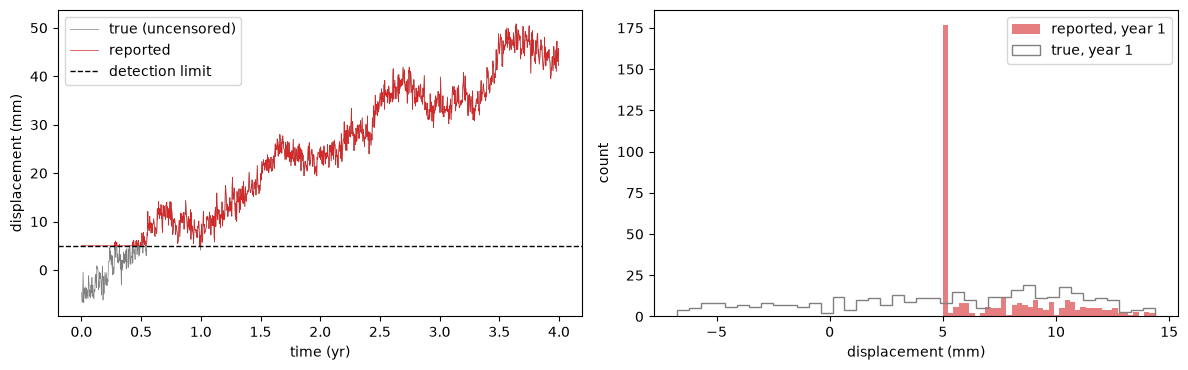

fraction of samples censored: 0.120
trend fit on reported values:   11.59 mm/yr
trend fit on uncensored values: 12.44 mm/yr


In [13]:
import matplotlib.pyplot as plt

# A 4-year GNSS displacement series moving at 12 mm/yr, reported by a
# sensor that cannot resolve displacements below 5 mm
gnss = mlgeo_synth.gnss_series(n_years=4, velocity_mm_yr=12.0, seed=7)
censored, truth = mlgeo_synth.degrade_series(gnss, detection_limit_mm=5.0, seed=7)

t = np.arange(len(censored)) / 365.25  # time in years

fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
ax[0].plot(t, truth['clean'], lw=0.5, color='gray', label='true (uncensored)')
ax[0].plot(t, censored['disp_mm'], lw=0.5, color='tab:red', label='reported')
ax[0].axhline(5.0, color='k', ls='--', lw=1, label='detection limit')
ax[0].set_xlabel('time (yr)'); ax[0].set_ylabel('displacement (mm)')
ax[0].legend()
ax[1].hist(censored['disp_mm'][:365], bins=40, color='tab:red', alpha=0.6, label='reported, year 1')
ax[1].hist(truth['clean'][:365], bins=40, histtype='step', color='gray', label='true, year 1')
ax[1].set_xlabel('displacement (mm)'); ax[1].set_ylabel('count')
ax[1].legend()
plt.tight_layout()
plt.show()

print(f"fraction of samples censored: {censored['censored'].mean():.3f}")
print(f"trend fit on reported values:   {np.polyfit(t, censored['disp_mm'], 1)[0]:.2f} mm/yr")
print(f"trend fit on uncensored values: {np.polyfit(t, truth['clean'], 1)[0]:.2f} mm/yr")

Trois signatures à retenir. Premièrement, `isna()` rapporte **zéro** valeur manquante : des données censurées passent tous les contrôles d'absence. Deuxièmement, l'histogramme présente un amas de valeurs identiques exactement à la limite — un pic à un nombre suspicieusement rond est l'empreinte d'une censure (tout comme les zéros de masse volumique étaient l'empreinte d'un code sentinelle). Troisièmement, les statistiques sont biaisées dans une *direction prévisible* : la moyenne rapportée de la première année est trop haute, et la tendance ajustée trop basse, parce que chaque excursion basse a été remontée au plancher. Écarter les échantillons censurés ne répare rien — cela retire exactement les valeurs basses, ce qui est un biais pire encore. Les options honnêtes sont de modéliser la censure (méthodes de survie/tobit) ou de déclarer la limite à côté des données, comme l'exige la fiche de données de la leçon 2.13.

Un piège apparenté est le **changement d'instrument en cours d'enregistrement** : un capteur neuf à limite de détection plus basse, ou une station déplacée, change les statistiques de l'enregistrement sans aucun changement dans la physique. Une marche dans la variance ou le minimum d'un enregistrement est une question pour les métadonnées de la station avant d'être un résultat scientifique.

### L'absence informative

La section 4 a écarté des lignes au motif que les lacunes étaient « sans rapport avec les valeurs elles-mêmes » — vrai ici *par construction*, puisque nous les avions plantées au hasard (le terme des statisticiens est **manquant complètement au hasard**, MCAR pour *missing completely at random*). Les instruments réels sont rarement aussi obligeants. La station hydrométrique se noie pendant la crue cévenole qu'elle devait mesurer ; l'antenne GNSS se tait sous la charge de neige de la tempête hivernale ; l'équipe de terrain saute le site quand la route est emportée. Dans chaque cas, la valeur manque *à cause de* la valeur qui aurait été mesurée (**manquant non au hasard**, MNAR), et écarter ces lignes supprime systématiquement les extrêmes — les crues, les tempêtes — qui sont probablement ce qui intéresse le plus l'analyse. Les zéros de MgO plus haut dans cette leçon étaient la même idée à l'envers : les valeurs « suspectes » étaient concentrées dans les granites évolués, si bien que les retirer aurait réécrit la géologie. Avant d'écarter ou d'imputer quoi que ce soit, demandez-vous quel processus a créé la lacune. Si la réponse fait intervenir la grandeur mesurée, l'absence est elle-même une donnée, et elle a sa place dans la politique de données manquantes de votre fiche de données.

## 6. Analyse des corrélations

Les corrélations entre caractéristiques (*features*) vous disent quelles mesures portent une information redondante et laissent entrevoir la physique derrière la table. Nous calculons deux matrices :

* la corrélation de **Pearson** mesure les relations *linéaires* ;
* la corrélation de rang de **Spearman** mesure les relations *monotones*. Elle est robuste aux valeurs aberrantes et aux liens non linéaires mais monotones, courants en géochimie.

La colonne ``label`` est une chaîne de caractères : gardez donc d'abord les seules colonnes numériques.

In [14]:
df_numerical = df_cleaned.select_dtypes(include='number')
df_numerical.head()

,SIO2,AL2O3,FEO,MGO,CAO,NA2O,K2O,density_g_cm3,mag_susc_si
0,45.911630,16.274633,11.975374,9.696094,12.753069,2.080147,0.000000,3.006341,0.000440
1,68.266983,14.422233,4.859297,2.240226,4.761345,3.047384,3.424764,2.692516,0.000165
2,50.417246,15.268785,8.214010,5.851874,10.378347,2.554201,1.235895,2.939080,0.001338
3,46.502363,14.569045,11.726829,7.618624,12.454581,1.244922,0.000000,3.001760,0.001120
4,68.305243,13.592871,3.457937,2.516258,3.781839,3.270665,3.738746,2.682556,0.000087


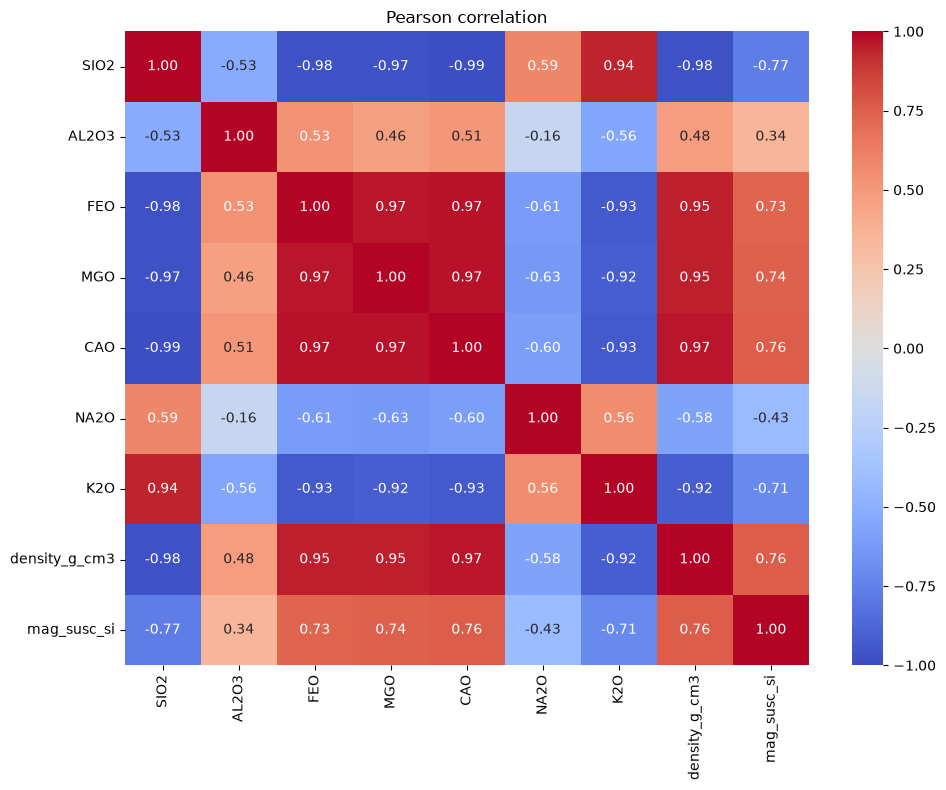

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df_numerical.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Pearson correlation')
plt.tight_layout()
plt.show()

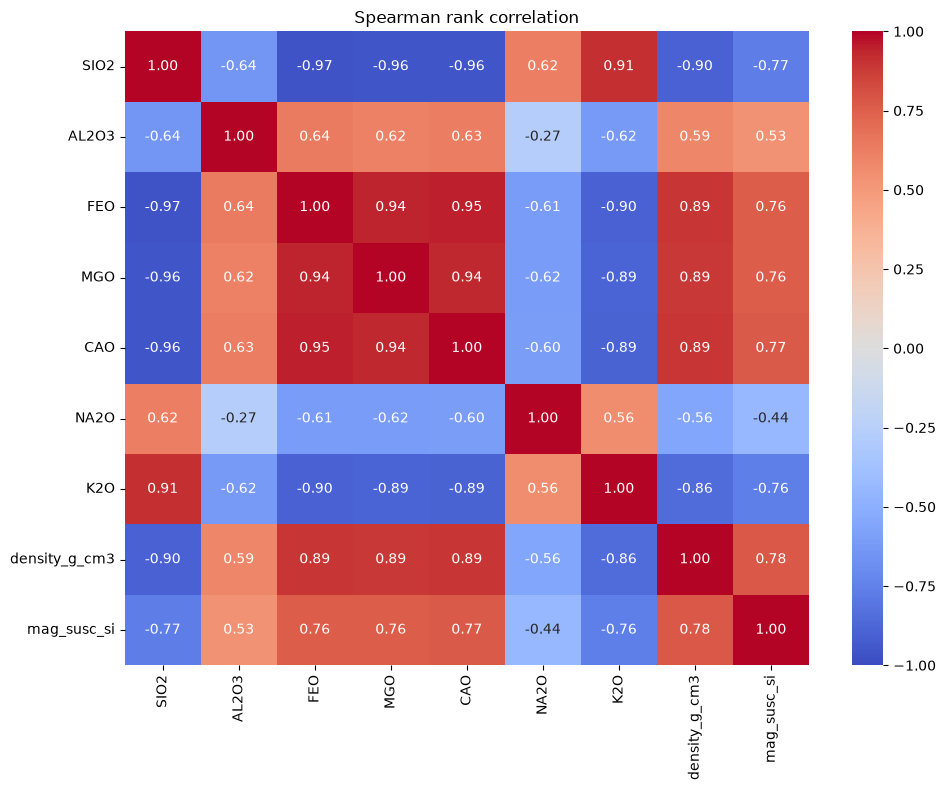

In [16]:
spearman_corr_matrix = df_numerical.corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(spearman_corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Spearman rank correlation')
plt.tight_layout()
plt.show()

Lisez les deux matrices côte à côte. SiO2 est fortement anticorrélé avec FeO, MgO et CaO, et positivement corrélé avec K2O. La masse volumique suit les oxydes mafiques et s'anticorrèle avec SiO2. Là où la valeur de Spearman est nettement plus forte que celle de Pearson, la relation est monotone mais non linéaire ; la susceptibilité magnétique en est un cas typique, puisqu'elle s'étend sur plusieurs ordres de grandeur.

Une raison structurelle des corrélations négatives : les analyses d'oxydes sont des **données de composition**. Les valeurs en wt% des oxydes majeurs somment à environ 100 : si un oxyde monte, les autres doivent descendre. Cet effet de fermeture inscrit de la corrélation négative dans la table, indépendamment de toute pétrologie. Gardez-le en tête avant d'interpréter chaque entrée négative comme un processus géologique.

## 7. Distributions des caractéristiques par lithologie

Les matrices de corrélation mélangent toutes les classes. Pour voir quelles caractéristiques séparent les lithologies, tracez la distribution de chaque caractéristique par classe.

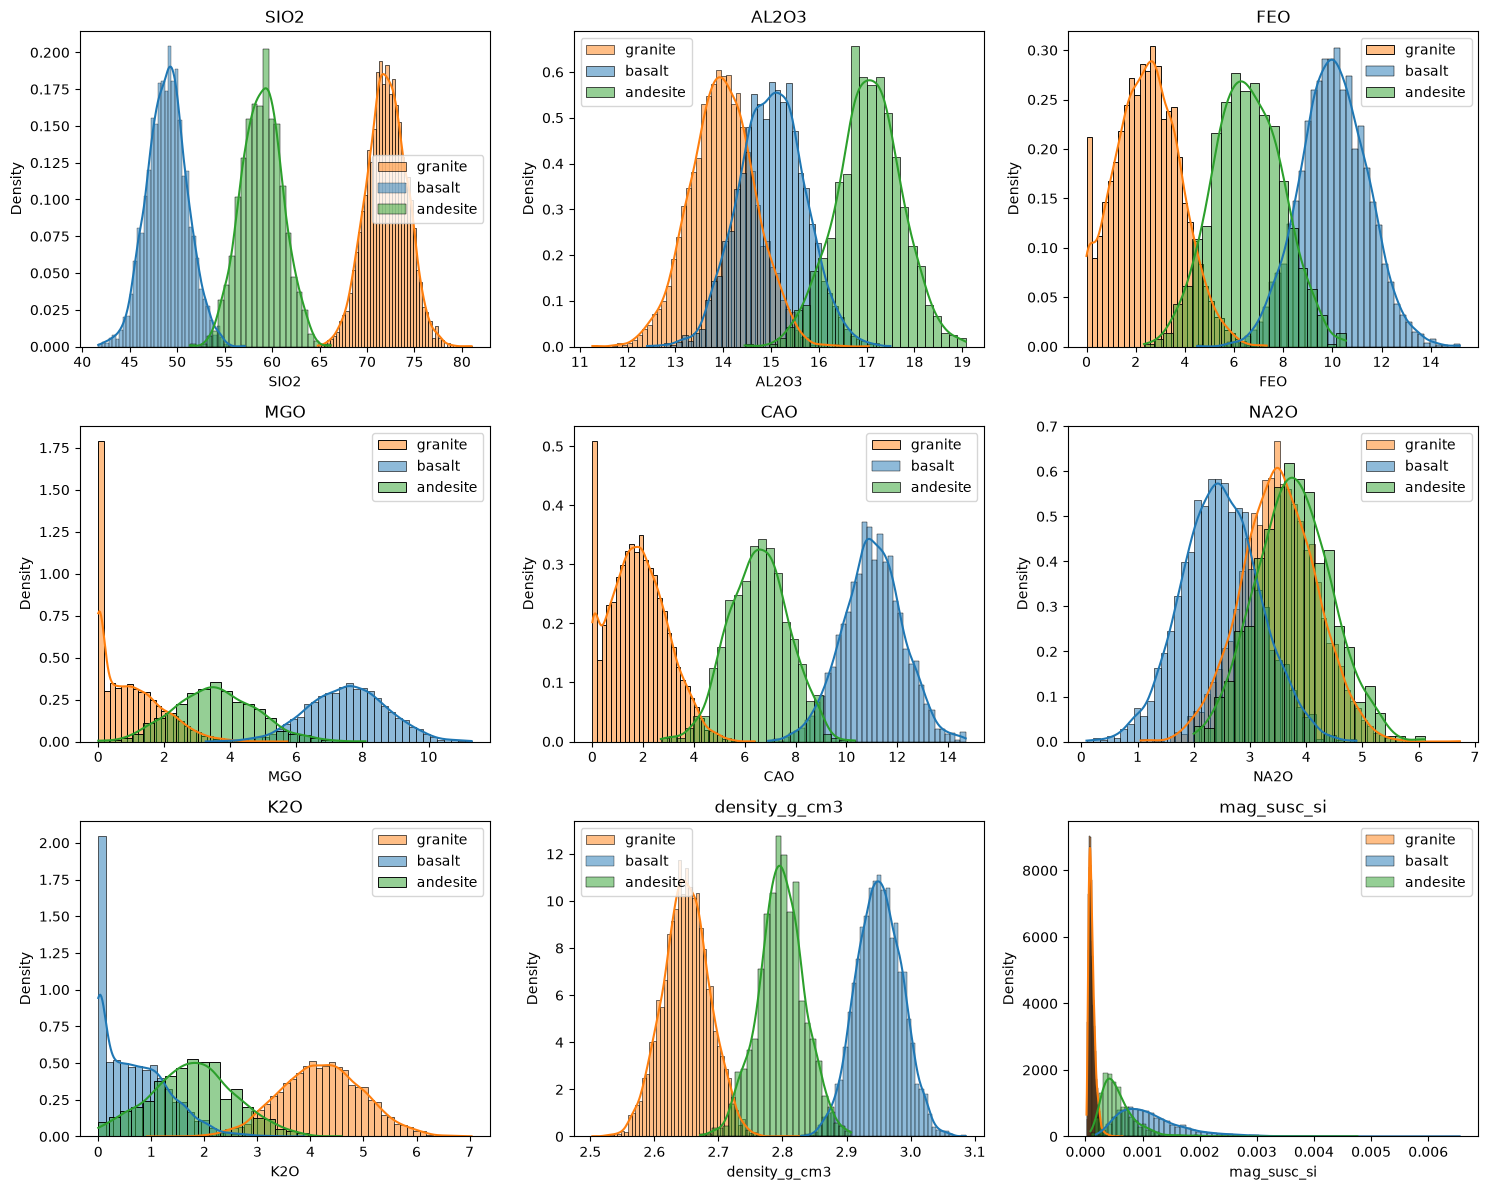

In [17]:
granite = df_cleaned[df_cleaned['label'] == 'granite']
basalt = df_cleaned[df_cleaned['label'] == 'basalt']
andesite = df_cleaned[df_cleaned['label'] == 'andesite']

features = ['SIO2', 'AL2O3', 'FEO', 'MGO', 'CAO', 'NA2O', 'K2O', 'density_g_cm3', 'mag_susc_si']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for ax, feature in zip(axes.ravel(), features):
    sns.histplot(granite[feature], kde=True, color='tab:orange', label='granite', stat='density', ax=ax)
    sns.histplot(basalt[feature], kde=True, color='tab:blue', label='basalt', stat='density', ax=ax)
    sns.histplot(andesite[feature], kde=True, color='tab:green', label='andesite', stat='density', ax=ax)
    ax.set_title(feature)
    ax.legend()
plt.tight_layout()
plt.show()

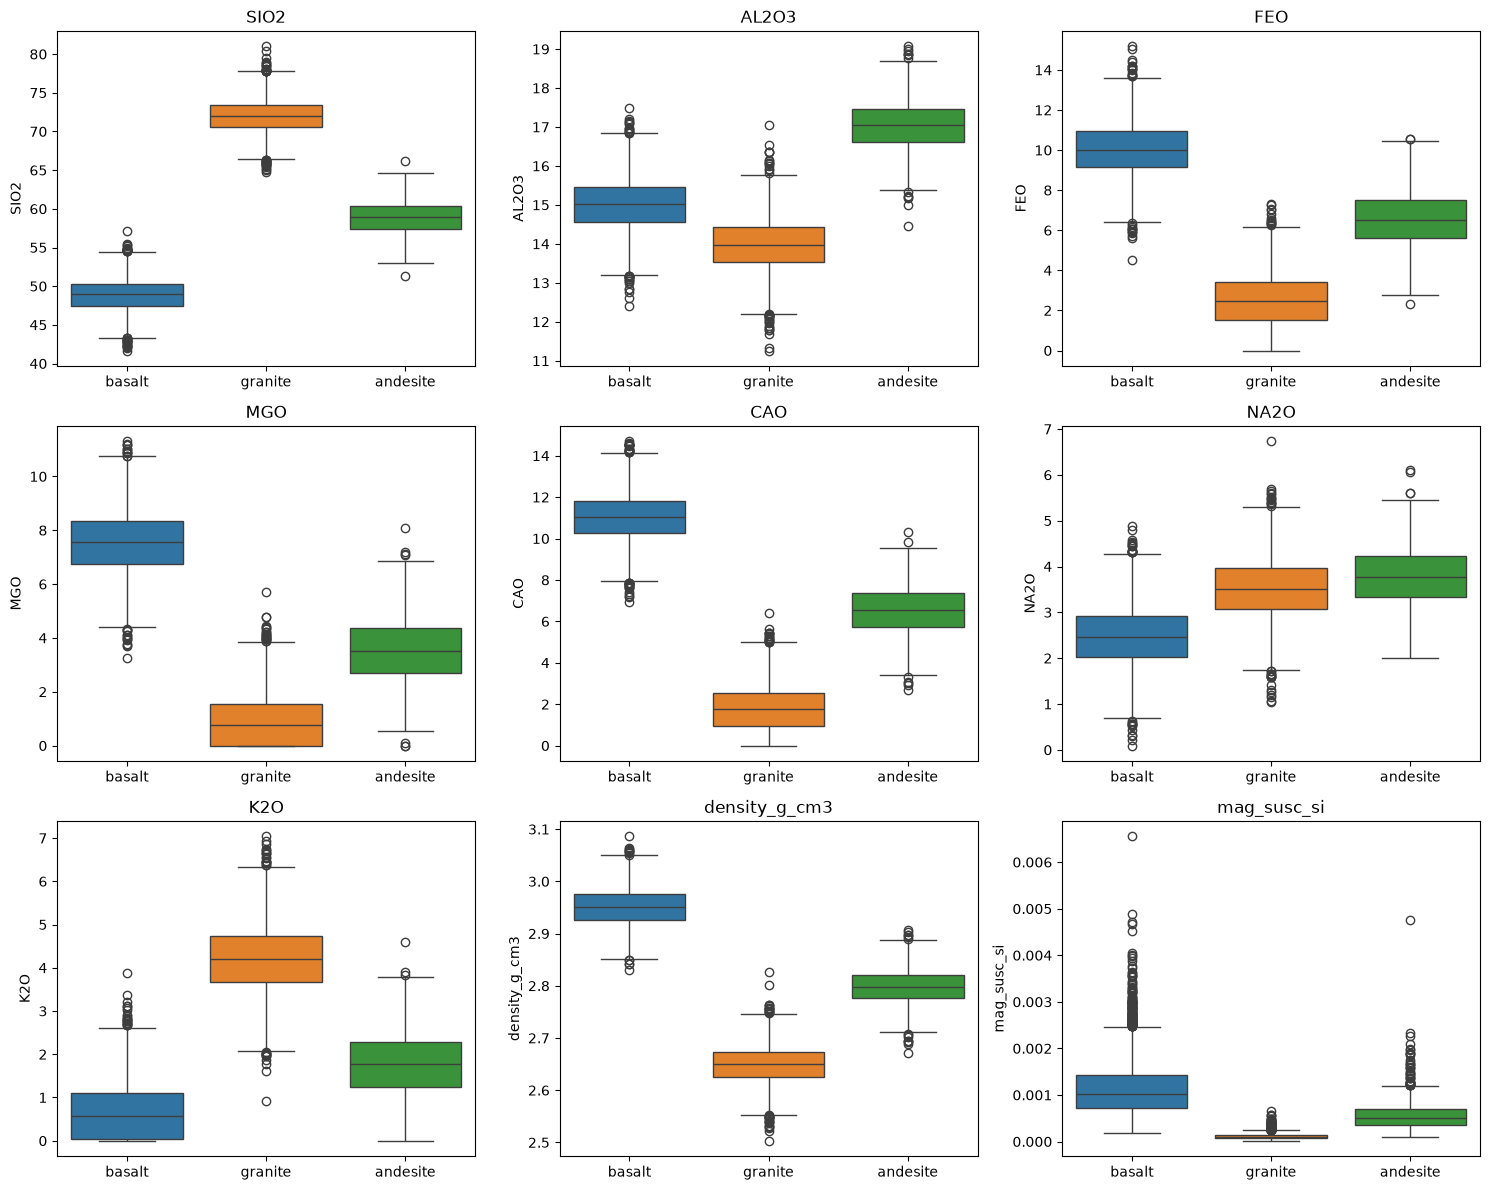

In [18]:
# Boxplots give a compact per-class view of the same information
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for ax, feature in zip(axes.ravel(), features):
    sns.boxplot(data=df_cleaned, x='label', y=feature, hue='label', ax=ax)
    ax.set_title(feature)
    ax.set_xlabel('')
plt.tight_layout()
plt.show()

Certaines caractéristiques séparent les classes presque complètement ; d'autres se recouvrent fortement. Certaines distributions paraissent à peu près gaussiennes, d'autres sont asymétriques ou à queues lourdes. Pour quantifier la forme, calculez l'asymétrie (*skewness*) et le kurtosis en plus des moments habituels.

In [19]:
from scipy.stats import skew, kurtosis

def summarize_distribution(frame, features):
    summary = {}
    for feature in features:
        values = frame[feature].to_numpy(dtype=float)
        summary[feature] = {
            'mean': values.mean(),
            'median': np.median(values),
            'std': values.std(),
            'skewness': skew(values),
            'kurtosis': kurtosis(values),
        }
    return pd.DataFrame(summary)

print("Granite:")
print(summarize_distribution(granite, features).round(3))
print("\nBasalt:")
print(summarize_distribution(basalt, features).round(3))
print("\nAndesite:")
print(summarize_distribution(andesite, features).round(3))

Granite:
            SIO2   AL2O3    FEO    MGO    CAO   NA2O    K2O  density_g_cm3  \
mean      72.043  13.981  2.481  0.947  1.799  3.511  4.213          2.650   
median    72.040  13.977  2.477  0.756  1.753  3.503  4.210          2.649   
std        2.128   0.677  1.319  0.930  1.129  0.672  0.785          0.037   
skewness  -0.007  -0.001  0.180  0.880  0.332 -0.003  0.033         -0.006   
kurtosis   0.015   0.121 -0.326  0.191 -0.370  0.061 -0.067          0.058   

          mag_susc_si  
mean            0.000  
median          0.000  
std             0.000  
skewness        1.796  
kurtosis        5.938  

Basalt:
            SIO2   AL2O3     FEO    MGO     CAO   NA2O    K2O  density_g_cm3  \
mean      48.931  15.014  10.044  7.547  11.032  2.479  0.677          2.951   
median    48.976  15.028  10.029  7.564  11.025  2.470  0.571          2.951   
std        2.121   0.681   1.367  1.187   1.187  0.690  0.631          0.036   
skewness   0.001  -0.002   0.017 -0.031  -0.038  

Une asymétrie proche de 0 et un kurtosis proche de 0 (scipy suit la convention du kurtosis d'excès) indiquent une forme à peu près gaussienne. Une forte asymétrie positive, comme pour la susceptibilité magnétique, signale une queue droite lourde ; ces caractéristiques sont souvent passées au logarithme avant modélisation.

Sauvegardez la table nettoyée pour les chapitres suivants.

In [20]:
df_cleaned.to_csv('cleaned_geochem.csv', index=False)
df_cleaned.describe()

,SIO2,AL2O3,FEO,MGO,CAO,NA2O,K2O,density_g_cm3,mag_susc_si
count,9499.000000,9499.000000,9499.000000,9499.000000,9499.000000,9499.000000,9499.000000,9499.000000,9499.000000
mean,62.547694,14.655570,5.564598,3.542369,5.542651,3.173276,2.717094,2.771041,0.000526
std,10.981083,1.153150,3.765145,3.235125,4.441995,0.853688,1.822599,0.144498,0.000609
min,41.686955,11.262724,0.000000,0.000000,0.000000,0.092059,0.000000,2.503250,0.000018
25%,50.039458,13.859048,2.323911,0.624757,1.623670,2.579347,0.917860,2.645449,0.000094
50%,69.082701,14.484437,4.261370,2.244728,3.443124,3.209799,3.161037,2.700964,0.000199
75%,72.246668,15.246425,9.320874,6.890419,10.420669,3.771248,4.296074,2.931204,0.000826
max,81.019298,19.072472,15.184024,11.303776,14.695311,6.731240,7.037632,3.086072,0.006552


## 8. Exercice

Répondez à chaque question par du code et une courte justification écrite.

1. **Corrélations et fermeture.** À partir de la matrice de Pearson, listez les trois anticorrélations les plus fortes avec SiO2. Quelle part de cette anticorrélation relève de la pétrologie (les minéraux mafiques se fractionnent à mesure que les liquides évoluent) et quelle part de l'effet de fermeture (les oxydes majeurs somment à ~100 wt%, donc si l'un monte, les autres descendent) ? Proposez une vérification qui pourrait aider à séparer les deux explications.
2. **La caractéristique la plus discriminante.** À l'aide des histogrammes par classe et des statistiques descriptives, quelle caractéristique, à elle seule, sépare le mieux les trois lithologies ? Appuyez votre choix quantitativement, par exemple en comparant, pour chaque caractéristique, l'écart entre moyennes de classes aux écarts-types des classes.
3. **Déséquilibre des classes.** Les granites représentent plus de la moitié de la table et les andésites environ 10 %. Si vous entraîniez un classifieur sur cette table et ne mesuriez que l'exactitude globale, quelle exactitude atteindrait un modèle qui prédit toujours « granite » ? Qu'est-ce que cela implique pour la manière d'évaluer un futur classifieur sur ce jeu de données ?
4. **Retour sur les zéros.** Supposez qu'un collègue vous remette une version de cette table où tous les zéros de MgO ont déjà été remplacés par NaN puis écartés. Quelle classe perdrait le plus d'échantillons, et comment la distribution de SiO2 des granites restants changerait-elle ?

In [21]:
# your answers here